In [2]:
#pandas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import csv

In [3]:
#csv coma separador
df = pd.read_csv('final.csv', sep=';')
# elimminar columna Fecha,Nombre,Apellido, Correos, G1, G2, G3, G4, G5,G6,G7
df = df.drop(columns=['Fecha', 'Nombre', 'Apellido', 'Correos', 'G1', 'G2', 'G3', 'G4', 'G5', 'G6', 'G7'])
# Primero, reemplazamos las comas decimales por puntos en caso de que SCORE_NORM las tenga
df['SCORE_NORM'] = df['SCORE_NORM'].str.replace(',', '.').astype(float)
print(df.head())


   GOLD_SCORE  SCORE_NORM                          C1  \
0        31.0        0.60  B mucho más compleja que A   
1        24.0        0.46  B mucho más compleja que A   
2         4.0        0.08        B más compleja que A   
3        10.0        0.19        B más compleja que A   
4         2.0        0.04        A más compleja que B   

                           L1                          L2  \
0  A mucho más compleja que B          Igual de complejas   
1        A más compleja que B          Igual de complejas   
2        A más compleja que B          Igual de complejas   
3          Igual de complejas        A más compleja que B   
4  B mucho más compleja que A  A mucho más compleja que B   

                           L3                          L4  \
0          Igual de complejas  A mucho más compleja que B   
1        B más compleja que A        B más compleja que A   
2  B mucho más compleja que A  A mucho más compleja que B   
3        B más compleja que A        A más com

In [4]:
# ----------------------------
# 1. Mapeo de respuestas a valores numéricos
# ----------------------------
score_map = {
    "A mucho más compleja que B": 2,
    "A más compleja que B": 1,
    "Igual de complejas": 0,
    "B más compleja que A": -1,
    "B mucho más compleja que A": -2
}

# ----------------------------
# 2. Identificar columnas de cada tipo
# ----------------------------
C_cols = [c for c in df.columns if c.startswith("C")]
L_cols = [c for c in df.columns if c.startswith("L")]
H_cols = [c for c in df.columns if c.startswith("H")]

# ----------------------------
# 3. Función para saber si el audio de interés es A o B
# ----------------------------
def my_audio_is_A(col_name):
    base = col_name.split("_")[0]  # elimina cualquier sufijo
    if base.startswith(("L","H")):
        num = int(base[1:])
        return num % 2 == 0  # pares → A, impares → B
    return True

# ----------------------------
# 4. Convertir respuestas a valores numéricos
# ----------------------------
for col in L_cols + H_cols + C_cols:
    df[col + "_score"] = df[col].map(score_map)

# ----------------------------
# 5. Ajustar signo para L y H según si nuestro audio es A o B
# ----------------------------
for col in L_cols + H_cols:
    val_col = col + "_score"
    df[val_col] = df[val_col].apply(lambda x: x if my_audio_is_A(col) else -x)

# ----------------------------
# 6. Filtrar participantes que fallaron la validación (C1 y C2)
# ----------------------------
# Mantener solo participantes que dijeron que B era más compleja en ambos ítems de control
valid_mask = (df["C1_score"] < 0) & (df["C2_score"] < 0)
df_filtered = df[valid_mask].copy()

# Filtrar solo filas con datos en columnas relevantes
df_valid = df.dropna(subset=["C1", "C2", "SCORE_NORM"])

print(f"Número total de participantes reales: {len(df_valid)}")
print(f"Número de participantes después de filtrar: {len(df_filtered)}")

# Crear bins para SCORE_NORM
bins = [0, 0.33, 0.66, 1.0]
labels = ["Bajo", "Medio", "Alto"]
# Crear columna score_bin
df_filtered["score_bin"] = pd.cut(df_filtered["SCORE_NORM"], bins=bins, labels=labels, include_lowest=True)


# ----------------------------
# 7. Calcular PHC promedio solo para L y H
# ----------------------------
score_cols_LH = [c + "_score" for c in L_cols + H_cols]
df_filtered["PHC"] = df_filtered[score_cols_LH].mean(axis=1)
df_filtered["PHC_L"] = df_filtered[[c + "_score" for c in L_cols]].mean(axis=1)
df_filtered["PHC_H"] = df_filtered[[c + "_score" for c in H_cols]].mean(axis=1)

avg_phc_total = df_filtered["PHC"].mean()
std_phc_total = df_filtered["PHC"].std()
avg_phc_L = df_filtered["PHC_L"].mean()
std_phc_L = df_filtered["PHC_L"].std()
avg_phc_H = df_filtered["PHC_H"].mean()
std_phc_H = df_filtered["PHC_H"].std()

print(f"Promedio total PHC: {avg_phc_total:.3f} ± {std_phc_total:.3f}")
print(f"Promedio PHC_L: {avg_phc_L:.3f} ± {std_phc_L:.3f}")
print(f"Promedio PHC_H: {avg_phc_H:.3f} ± {std_phc_H:.3f}")

# ----------------------------
# 8. Crear dataset "long" para PHC por audio
# ----------------------------
audio_records = []
for col in L_cols + H_cols:
    val_col = col + "_score"
    for idx, score in enumerate(df_filtered[val_col]):
        audio_name = f"A_{col}" if my_audio_is_A(col) else f"B_{col}"
        audio_records.append({
            "participant_id": df_filtered.index[idx],
            "audio": audio_name,
            "score": score,
            "block": "L" if col in L_cols else "H"
        })

df_audio = pd.DataFrame(audio_records)
df_audio = df_audio[~df_audio['audio'].str.contains("_score")]

# ----------------------------
# PHC por audio y bloque, limpio y ordenado
# ----------------------------
phc_by_audio = df_audio.groupby(["block","audio"])["score"].agg(["mean","std","count"]).reset_index()

# Redondear y renombrar columnas
phc_by_audio = phc_by_audio.rename(columns={"mean":"Media","std":"Desviación","count":"Conteo"})
phc_by_audio[["Media","Desviación"]] = phc_by_audio[["Media","Desviación"]].round(3)

# Orden natural de bloques y audios
phc_by_audio = phc_by_audio.sort_values(by=["block","audio"]).reset_index(drop=True)

print("\nPHC por audio y bloque (ordenado):")
print(phc_by_audio)

# ----------------------------
# PHC por rango de SCORE_NORM
# ----------------------------
avg_phc_bin = df_filtered.groupby("score_bin")[["PHC","PHC_L","PHC_H"]].agg(["mean","std","count"])

# Aplanar multi-índice
avg_phc_bin = df_filtered.groupby("score_bin")[["PHC","PHC_L","PHC_H"]].agg(["mean","std","count"])
avg_phc_bin.columns = ["_".join(col).strip() for col in avg_phc_bin.columns.values]
avg_phc_bin = avg_phc_bin.round(3)

print("\nPHC por rango de SCORE_NORM (ordenado y redondeado):")
print(avg_phc_bin)


Número total de participantes reales: 53
Número de participantes después de filtrar: 45
Promedio total PHC: 0.228 ± 0.634
Promedio PHC_L: 0.074 ± 0.736
Promedio PHC_H: 0.381 ± 0.725

PHC por audio y bloque (ordenado):
   block audio  Media  Desviación  Conteo
0      H  A_H2  0.311       1.258      45
1      H  A_H4  0.400       1.074      45
2      H  A_H6 -0.200       1.140      45
3      H  B_H1  0.044       1.397      45
4      H  B_H3  0.933       1.250      45
5      H  B_H5  0.800       1.375      45
6      L  A_L2  0.022       1.196      45
7      L  A_L4  0.111       1.153      45
8      L  A_L6 -0.422       1.305      45
9      L  B_L1  0.289       1.308      45
10     L  B_L3 -0.111       1.352      45
11     L  B_L5  0.556       1.216      45

PHC por rango de SCORE_NORM (ordenado y redondeado):
           PHC_mean  PHC_std  PHC_count  PHC_L_mean  PHC_L_std  PHC_L_count  \
score_bin                                                                     
Bajo          0.167    0

/var/folders/j8/8v21hcxs2wg1v9dljnmt6sfr0000gn/T/ipykernel_6458/961476921.py:117: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_phc_bin = df_filtered.groupby("score_bin")[["PHC","PHC_L","PHC_H"]].agg(["mean","std","count"])
/var/folders/j8/8v21hcxs2wg1v9dljnmt6sfr0000gn/T/ipykernel_6458/961476921.py:120: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_phc_bin = df_filtered.groupby("score_bin")[["PHC","PHC_L","PHC_H"]].agg(["mean","std","count"])


Number of participants per musical training level:
score_bin
Bajo     17
Medio    18
Alto     10
Name: count, dtype: int64

Descriptive statistics for SCORE_NORM:
count    45.000
mean      0.418
std       0.281
min       0.000
25%       0.120
50%       0.400
75%       0.600
max       0.980
Name: SCORE_NORM, dtype: float64


/var/folders/j8/8v21hcxs2wg1v9dljnmt6sfr0000gn/T/ipykernel_6458/2397851491.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


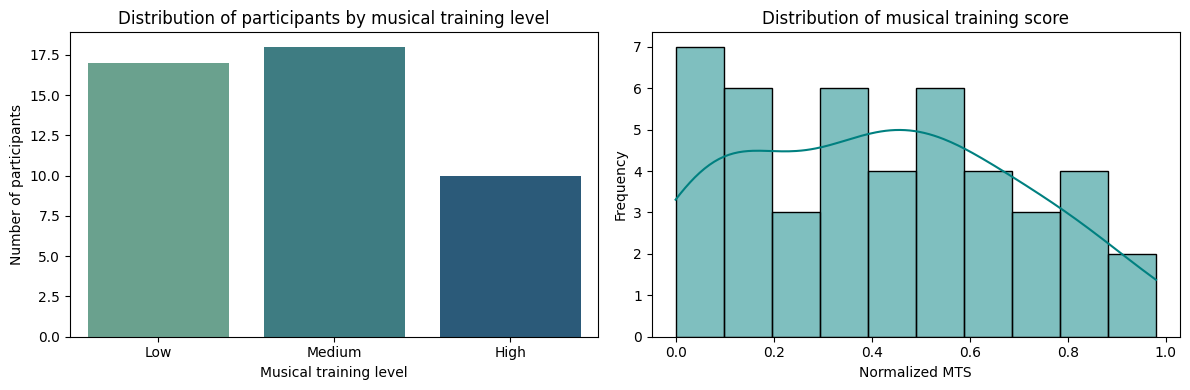


Mean and standard deviation of SCORE_NORM by musical training level:

            Mean  Std. Dev.  Participants
score_bin                                
Bajo       0.122      0.095            17
Medio      0.480      0.093            18
Alto       0.810      0.102            10

Total participants: 45


/var/folders/j8/8v21hcxs2wg1v9dljnmt6sfr0000gn/T/ipykernel_6458/2397851491.py:47: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_filtered.groupby("score_bin")["SCORE_NORM"]


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ----------------------------
# 1 y 2. Two plots together: categorical and continuous distributions
# ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))  # 1 fila, 2 columnas

# Plot 1: Distribution of participants by musical training level (categorical)
sns.countplot(
    data=df_filtered, 
    x="score_bin", 
    palette="crest", 
    order=["Bajo","Medio","Alto"], 
    ax=axes[0]
)
axes[0].set_title("Distribution of participants by musical training level", fontsize=12)
axes[0].set_xlabel("Musical training level")
axes[0].set_ylabel("Number of participants")
axes[0].set_xticks([0,1,2])
axes[0].set_xticklabels(["Low","Medium","High"])  # categorical labels in English

# Print counts for categorical plot
counts = df_filtered["score_bin"].value_counts().reindex(["Bajo","Medio","Alto"]).fillna(0).astype(int)
print("Number of participants per musical training level:")
print(counts)

# Plot 2: Continuous distribution of musical training score (SCORE_NORM)
sns.histplot(df_filtered["SCORE_NORM"], kde=True, bins=10, color="teal", ax=axes[1])
axes[1].set_title("Distribution of musical training score", fontsize=12)
axes[1].set_xlabel("Normalized MTS")
axes[1].set_ylabel("Frequency")

# Print descriptive statistics for continuous plot
score_stats = df_filtered["SCORE_NORM"].describe().round(3)
print("\nDescriptive statistics for SCORE_NORM:")
print(score_stats)

plt.tight_layout()
plt.show()

# ----------------------------
# 3. Mean and standard deviation of SCORE_NORM by group
# ----------------------------
summary = (
    df_filtered.groupby("score_bin")["SCORE_NORM"]
    .agg(["mean", "std", "count"])
    .round(3)
    .rename(columns={"mean": "Mean", "std": "Std. Dev.", "count": "Participants"})
)

print("\nMean and standard deviation of SCORE_NORM by musical training level:\n")
print(summary.to_string())

# Total number of participants
print("\nTotal participants:", df_filtered.shape[0])


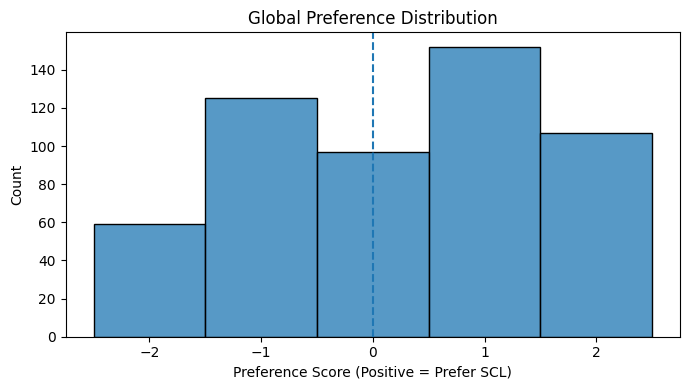

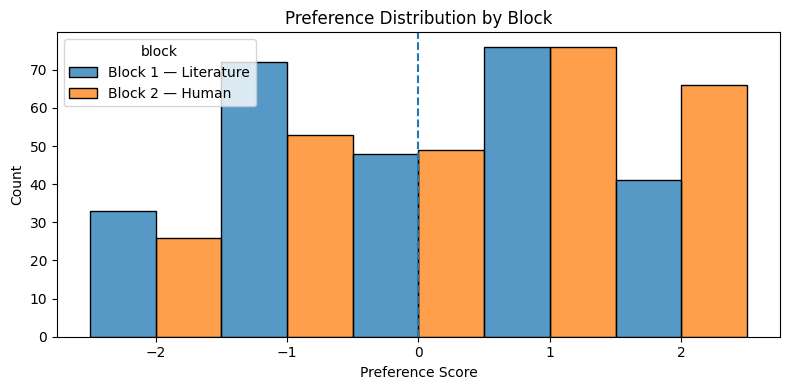

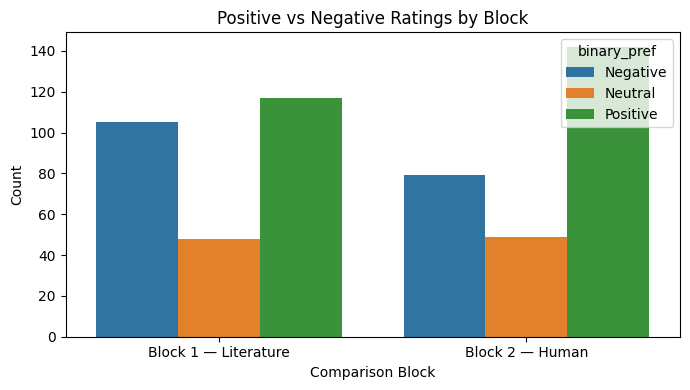


PHC Summary by Block:
                       mean    std  count
block                                    
Block 1 — Literature  0.074  1.283    270
Block 2 — Human       0.381  1.304    270


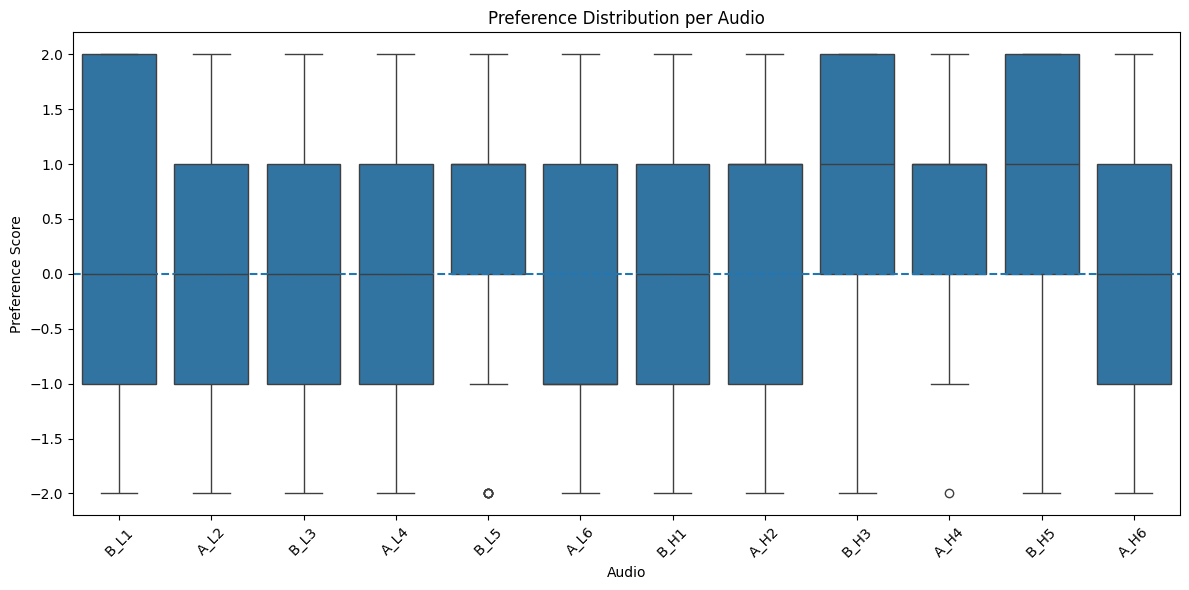

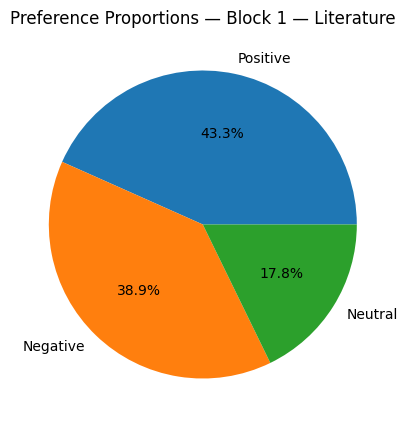

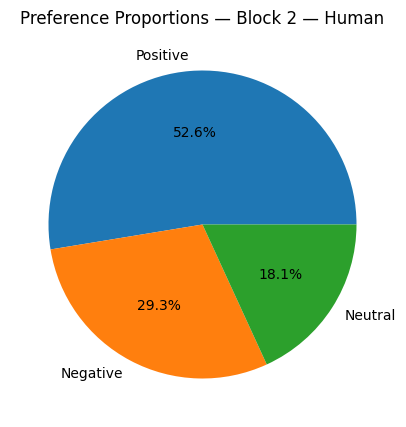

In [6]:
# ==========================================================
# BLOCK DETECTION FROM AUDIO LABEL (L vs H)
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ----------------------------------------------------------
# Crear columna BLOCK desde nombre del audio
# L → Block 1 (Literature)
# H → Block 2 (Human)
# ----------------------------------------------------------

def detect_block(audio_name):

    if "L" in audio_name:
        return "Block 1 — Literature"

    elif "H" in audio_name:
        return "Block 2 — Human"

    else:
        return "Unknown"

df_audio["block"] = df_audio["audio"].apply(detect_block)


# ==========================================================
# CATEGORÍAS DE PREFERENCIA
# ==========================================================

df_audio["model_preference"] = df_audio["score"].apply(
    lambda x: "Prefer SCL" if x > 0 else (
        "Prefer Reference" if x < 0 else "Tie"
    )
)

df_audio["binary_pref"] = df_audio["score"].apply(
    lambda x: "Positive" if x > 0 else (
        "Negative" if x < 0 else "Neutral"
    )
)

score_bins = [-2.5,-1.5,-0.5,0.5,1.5,2.5]


# ==========================================================
# FIGURE 1 — GLOBAL HISTOGRAM
# ==========================================================

plt.figure(figsize=(7,4))

sns.histplot(
    df_audio["score"],
    bins=score_bins
)

plt.xticks([-2,-1,0,1,2])

plt.axvline(0, linestyle="--")

plt.title("Global Preference Distribution")
plt.xlabel("Preference Score (Positive = Prefer SCL)")
plt.ylabel("Count")

plt.tight_layout()
plt.show()


# ==========================================================
# FIGURE 2 — BLOCK 1 vs BLOCK 2
# (CRÍTICO PARA TU PAPER)
# ==========================================================

plt.figure(figsize=(8,4))

sns.histplot(
    data=df_audio,
    x="score",
    hue="block",
    bins=score_bins,
    multiple="dodge"
)

plt.xticks([-2,-1,0,1,2])

plt.axvline(0, linestyle="--")

plt.title("Preference Distribution by Block")
plt.xlabel("Preference Score")
plt.ylabel("Count")

plt.tight_layout()
plt.show()


# ==========================================================
# FIGURE 3 — POSITIVE vs NEGATIVE POR BLOQUE
# ==========================================================

plt.figure(figsize=(7,4))

sns.countplot(
    data=df_audio,
    x="block",
    hue="binary_pref"
)

plt.title("Positive vs Negative Ratings by Block")
plt.xlabel("Comparison Block")
plt.ylabel("Count")

plt.tight_layout()
plt.show()


# ==========================================================
# FIGURE 4 — MEDIA PHC POR BLOQUE
# (MUY IMPORTANTE PARA RESULTADOS)
# ==========================================================

block_summary = (
    df_audio
    .groupby("block")["score"]
    .agg(["mean","std","count"])
    .round(3)
)

print("\nPHC Summary by Block:")
print(block_summary)


# ==========================================================
# FIGURE 5 — DISTRIBUCIÓN POR AUDIO
# ==========================================================

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df_audio,
    x="audio",
    y="score"
)

plt.axhline(0, linestyle="--")

plt.title("Preference Distribution per Audio")
plt.xlabel("Audio")
plt.ylabel("Preference Score")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


# ==========================================================
# FIGURE 6 — PIE CHART POR BLOQUE
# ==========================================================

for block_name in df_audio["block"].unique():

    subset = df_audio[
        df_audio["block"] == block_name
    ]

    counts = subset["binary_pref"].value_counts()

    plt.figure(figsize=(5,5))

    plt.pie(
        counts,
        labels=counts.index,
        autopct="%1.1f%%"
    )

    plt.title(f"Preference Proportions — {block_name}")

    plt.show()

/var/folders/j8/8v21hcxs2wg1v9dljnmt6sfr0000gn/T/ipykernel_6458/3119856410.py:51: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["block", "MSI_bin", "phc_type"])
/var/folders/j8/8v21hcxs2wg1v9dljnmt6sfr0000gn/T/ipykernel_6458/3119856410.py:56: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = summary.pivot_table(


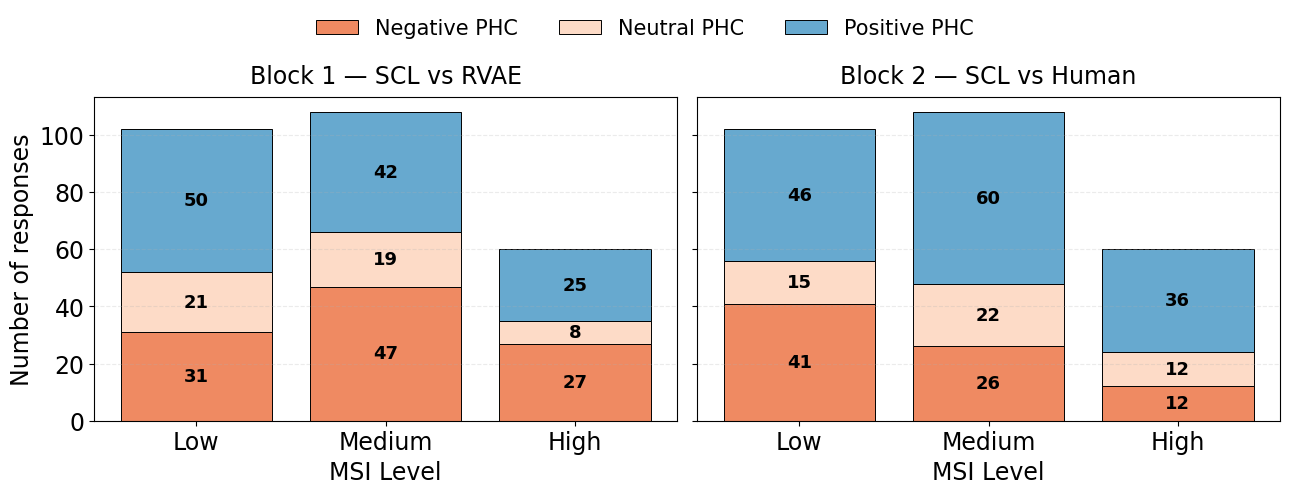


PHC × MSI × Block Summary (for paper):

Block 1 — SCL vs RVAE:
  MSI Low: Negative=31, Neutral=21, Positive=50
  MSI Medium: Negative=47, Neutral=19, Positive=42
  MSI High: Negative=27, Neutral=8, Positive=25
Block 2 — SCL vs Human:
  MSI Low: Negative=41, Neutral=15, Positive=46
  MSI Medium: Negative=26, Neutral=22, Positive=60
  MSI High: Negative=12, Neutral=12, Positive=36


In [7]:
# ==========================================================
# FIGURE 3 — STACKED BAR (PHC × MSI × BLOCK, PUBLICATION)
# ==========================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ----------------------------
# MSI BIN
# ----------------------------
df_filtered["MSI"] = df_filtered["SCORE_NORM"]

df_filtered["MSI_bin"] = pd.cut(
    df_filtered["MSI"],
    bins=[0, 0.33, 0.66, 1.0],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)

# ----------------------------
# merge MSI
# ----------------------------
df_audio = df_audio.merge(
    df_filtered[["MSI_bin"]],
    left_on="participant_id",
    right_index=True,
    how="left"
)

# ----------------------------
# PHC categories
# ----------------------------
df_audio["phc_type"] = np.where(
    df_audio["score"] > 0, "Positive PHC",
    np.where(df_audio["score"] < 0, "Negative PHC", "Neutral PHC")
)

# Colores más suaves (pastel controlado, legible en papel)
colors = {
    "Negative PHC": "#ef8a62",
    "Neutral PHC": "#fddbc7",
    "Positive PHC": "#67a9cf"
}

# ----------------------------
# aggregation
# ----------------------------
summary = (
    df_audio
    .groupby(["block", "MSI_bin", "phc_type"])
    .size()
    .reset_index(name="count")
)

pivot = summary.pivot_table(
    index=["block", "MSI_bin"],
    columns="phc_type",
    values="count",
    fill_value=0
).reset_index()

# ----------------------------
# BLOCK LABELS
# ----------------------------
block_label_map = {
    "Block 1 — Literature": "Block 1 — SCL vs RVAE",
    "Block 2 — Human": "Block 2 — SCL vs Human"
}

msi_order = ["Low", "Medium", "High"]
blocks = pivot["block"].unique()

# ==========================================================
# PLOT
# ==========================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for i, block in enumerate(blocks):

    ax = axes[i]
    sub = pivot[pivot["block"] == block].copy()

    sub["MSI_bin"] = pd.Categorical(sub["MSI_bin"], categories=msi_order, ordered=True)
    sub = sub.sort_values("MSI_bin")

    x = np.arange(len(sub))
    bottom = np.zeros(len(sub))

    for cat in ["Negative PHC", "Neutral PHC", "Positive PHC"]:

        vals = sub[cat].values if cat in sub.columns else np.zeros(len(sub))

        ax.bar(
            x,
            vals,
            bottom=bottom,
            color=colors[cat],
            edgecolor="black",
            linewidth=0.7
        )

        # ----------------------------
        # NUMEROS MÁS GRANDES Y LEGIBLES
        # ----------------------------
        for j, v in enumerate(vals):
            if v > 0:
                ax.text(
                    x[j],
                    bottom[j] + v / 2,
                    f"{int(v)}",
                    ha="center",
                    va="center",
                    fontsize=13,
                    fontweight="bold",
                    color="black"
                )

        bottom += vals

    # ----------------------------
    # AXES STYLE (PAPER)
    # ----------------------------
    ax.set_xticks(x)
    ax.set_xticklabels(sub["MSI_bin"], fontsize=17)

    ax.set_xlabel("MSI Level", fontsize=17)

    ax.set_title(block_label_map[block], fontsize=17, pad=10)

    ax.grid(axis="y", linestyle="--", alpha=0.25)

    ax.tick_params(axis='y', labelsize=17)

# ----------------------------
# GLOBAL LABELS
# ----------------------------
axes[0].set_ylabel("Number of responses", fontsize=17)

# ----------------------------
# LEGEND CLEAN
# ----------------------------
fig.legend(
    ["Negative PHC", "Neutral PHC", "Positive PHC"],
    loc="upper center",
    ncol=3,
    frameon=False,
    fontsize=15
)

plt.tight_layout(rect=[0, 0, 1, 0.90])

# ==========================================================
# VECTOR EXPORT (PUBLICATION QUALITY)
# ==========================================================
plt.savefig("phc_msi_blocks_publication.pdf", format="pdf", bbox_inches="tight")
plt.savefig("phc_msi_blocks_publication.svg", format="svg", bbox_inches="tight")

plt.show()


# Imprimir lo mismo de los plots pero en texto para el paper (números redondeados, ordenados, etc.)
print("\nPHC × MSI × Block Summary (for paper):\n")
for block in blocks:
    
    print(f"{block_label_map[block]}:")
    sub = pivot[pivot["block"] == block].copy()
    sub["MSI_bin"] = pd.Categorical(sub["MSI_bin"], categories=msi_order, ordered=True)
    sub = sub.sort_values("MSI_bin")

    for _, row in sub.iterrows():
        msi_level = row["MSI_bin"]
        neg = int(row["Negative PHC"]) if "Negative PHC" in row else 0
        neu = int(row["Neutral PHC"]) if "Neutral PHC" in row else 0
        pos = int(row["Positive PHC"]) if "Positive PHC" in row else 0
        print(f"  MSI {msi_level}: Negative={neg}, Neutral={neu}, Positive={pos}")

        